# Prediksi Kelulusan Mahasiswa menggunakan Random Forest

**Repositori**: Machine Learning  
**Topik**: Implementasi Random Forest pada Prediksi Kelulusan Mahasiswa  
**Dataset**: `dataset_kelulusan_mahasiswa.csv` (100.000 sampel)  

---

## Pendahuluan
Proyek ini menggunakan **Random Forest Classifier** untuk memprediksi status kelulusan mahasiswa berdasarkan IPK, jumlah mata kuliah tidak lulus, kehadiran, pekerjaan, dan metrik akademik lainnya.

### Pipeline:
1. **Data Acquisition** — Muat CSV
2. **EDA** — Analisis distribusi fitur dan target
3. **Data Preprocessing** — Encoding kategorikal, split train/test
4. **Modeling** — Random Forest Classifier
5. **Evaluation** — Confusion Matrix, Classification Report, ROC-AUC
6. **Feature Importance** — Analisis fitur paling berpengaruh

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded.")

Libraries loaded.


## 1. Data Acquisition
Memuat dataset kelulusan mahasiswa.

In [2]:
df = pd.read_csv('../../data/dataset_kelulusan_mahasiswa.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (100000, 10)
Columns: ['IPK', 'Mata Kuliah Tidak Lulus', 'Jumlah Cuti Akademik', 'Pekerjaan Sambil Kuliah', 'Jumlah Semester', 'Status Kelulusan', 'IPS Rata-rata', 'IPS Semester Akhir', 'IPS Tren', 'Kategori Kehadiran']


,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Pekerjaan Sambil Kuliah,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren,Kategori Kehadiran
0,3.87,5,1,Ya,13,1,3.299231,2.66,0.57,Sedang
1,3.65,5,1,Tidak,12,0,3.069167,3.56,1.21,Rendah
2,3.57,2,2,Tidak,11,1,2.955455,2.89,-0.59,Tinggi
3,3.96,0,1,Tidak,12,0,3.230833,2.63,-1.34,Rendah
4,2.27,0,0,Ya,9,1,3.066667,2.22,-1.14,Sedang


## 2. Exploratory Data Analysis

In [3]:
print("Informasi Dataset:")
print(df.info())

print("\nMissing Values:", df.isnull().sum().sum())

print("\nDistribusi Target (Status Kelulusan):")
print(df['Status Kelulusan'].value_counts())
print(df['Status Kelulusan'].value_counts(normalize=True).mul(100).round(2).apply(lambda x: f"{x}%"))

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   IPK                      100000 non-null  float64
 1   Mata Kuliah Tidak Lulus  100000 non-null  int64  
 2   Jumlah Cuti Akademik     100000 non-null  int64  
 3   Pekerjaan Sambil Kuliah  100000 non-null  object 
 4   Jumlah Semester          100000 non-null  int64  
 5   Status Kelulusan         100000 non-null  int64  
 6   IPS Rata-rata            100000 non-null  float64
 7   IPS Semester Akhir       100000 non-null  float64
 8   IPS Tren                 100000 non-null  float64
 9   Kategori Kehadiran       100000 non-null  object 
dtypes: float64(4), int64(4), object(2)
memory usage: 7.6+ MB
None

Missing Values: 0

Distribusi Target (Status Kelulusan):
Status Kelulusan
0    50038
1    49962
Name: count, dtype: int64
Status Kelulusan
0   

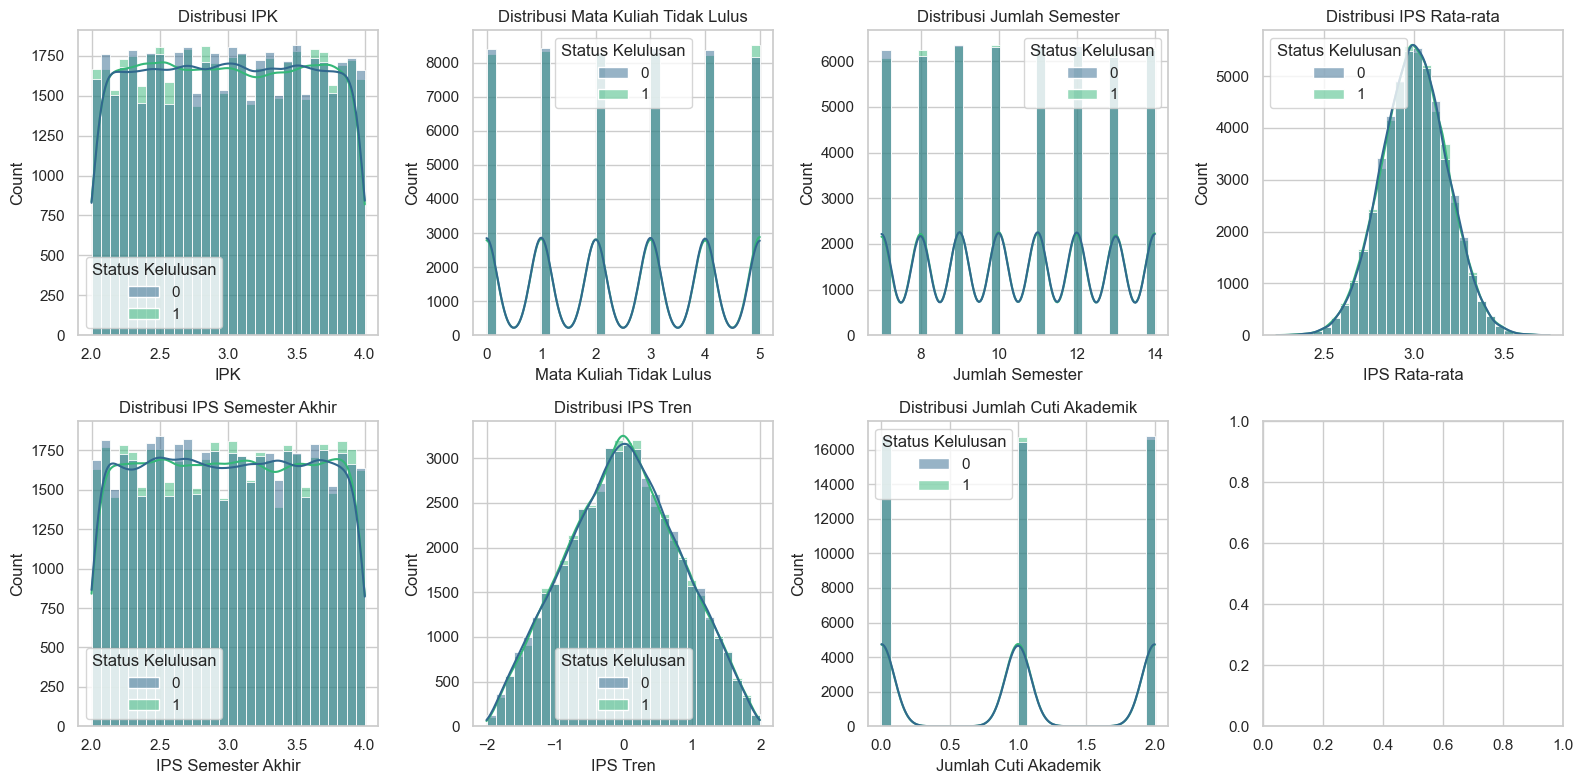

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
num_cols = ['IPK', 'Mata Kuliah Tidak Lulus', 'Jumlah Semester', 'IPS Rata-rata',
            'IPS Semester Akhir', 'IPS Tren', 'Jumlah Cuti Akademik']

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Status Kelulusan', bins=30, kde=True,
                 ax=axes[i // 4, i % 4], palette='viridis')
    axes[i // 4, i % 4].set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

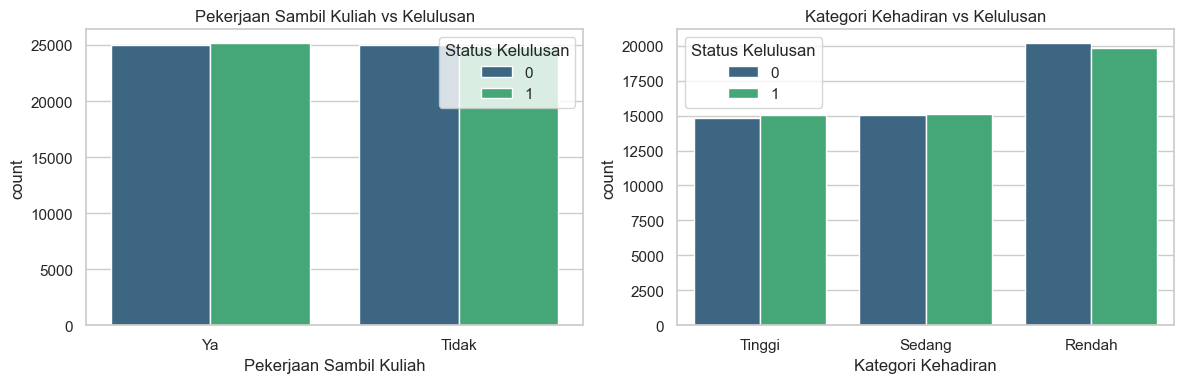

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Pekerjaan Sambil Kuliah', hue='Status Kelulusan',
              palette='viridis', ax=axes[0])
axes[0].set_title('Pekerjaan Sambil Kuliah vs Kelulusan')

sns.countplot(data=df, x='Kategori Kehadiran', hue='Status Kelulusan',
              order=['Tinggi', 'Sedang', 'Rendah'], palette='viridis', ax=axes[1])
axes[1].set_title('Kategori Kehadiran vs Kelulusan')

plt.tight_layout()
plt.show()

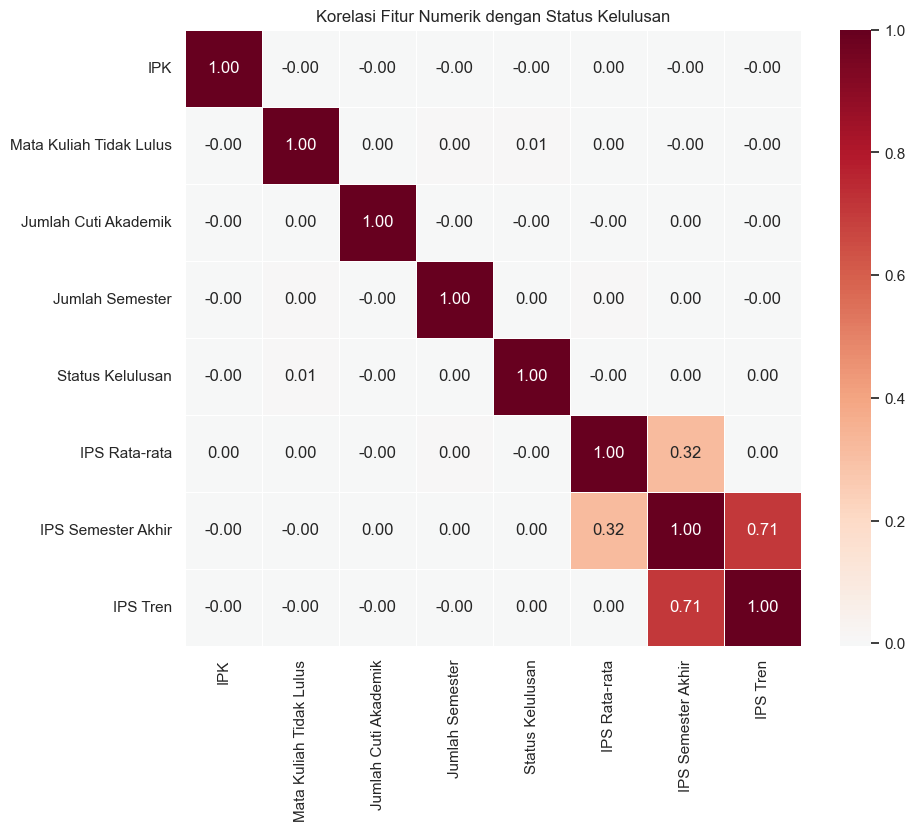

In [6]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Korelasi Fitur Numerik dengan Status Kelulusan')
plt.show()

## 3. Data Preprocessing
Encoding fitur kategorikal dan split train/test.

In [7]:
df_encoded = df.copy()

# Label Encoding untuk binary
df_encoded['Pekerjaan Sambil Kuliah'] = LabelEncoder().fit_transform(df_encoded['Pekerjaan Sambil Kuliah'])  # Tidak=0, Ya=1

# Ordinal Encoding untuk Kategori Kehadiran
kehadiran_map = {'Rendah': 0, 'Sedang': 1, 'Tinggi': 2}
df_encoded['Kategori Kehadiran'] = df_encoded['Kategori Kehadiran'].map(kehadiran_map)

X = df_encoded.drop('Status Kelulusan', axis=1)
y = df_encoded['Status Kelulusan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 80000 samples
Test size:  20000 samples


## 4. Model Training (Random Forest)
Melatih Random Forest dengan 100 trees.

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 5. Evaluation

Confusion Matrix:
[[5206 4802]
 [5295 4697]]


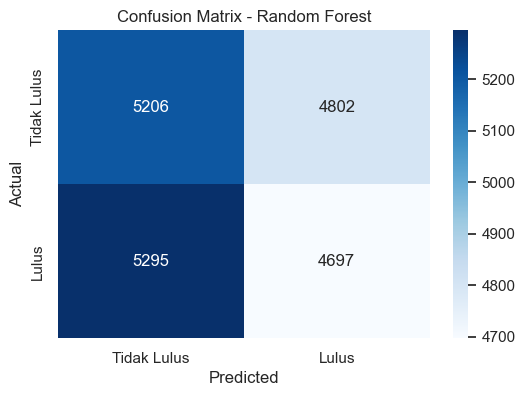


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.52      0.51     10008
           1       0.49      0.47      0.48      9992

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.50      0.50      0.49     20000



In [9]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Lulus', 'Lulus'],
            yticklabels=['Tidak Lulus', 'Lulus'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

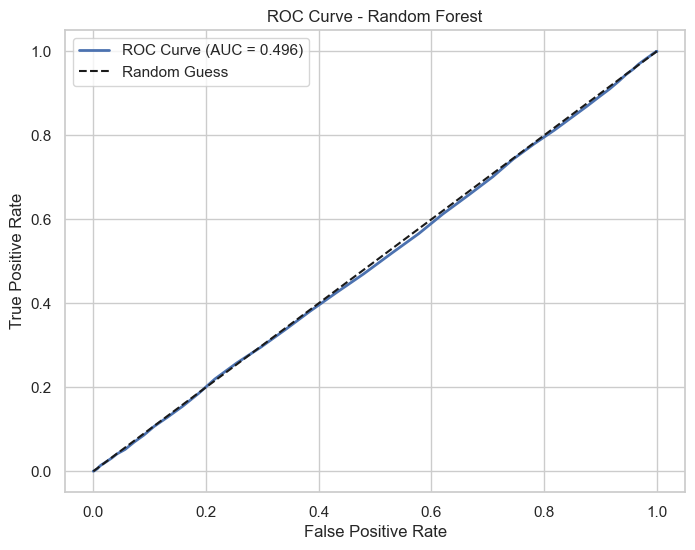

Accuracy: 0.4951
AUC-ROC: 0.4957


In [10]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

## 6. Feature Importance
Menampilkan fitur yang paling berpengaruh terhadap prediksi kelulusan.

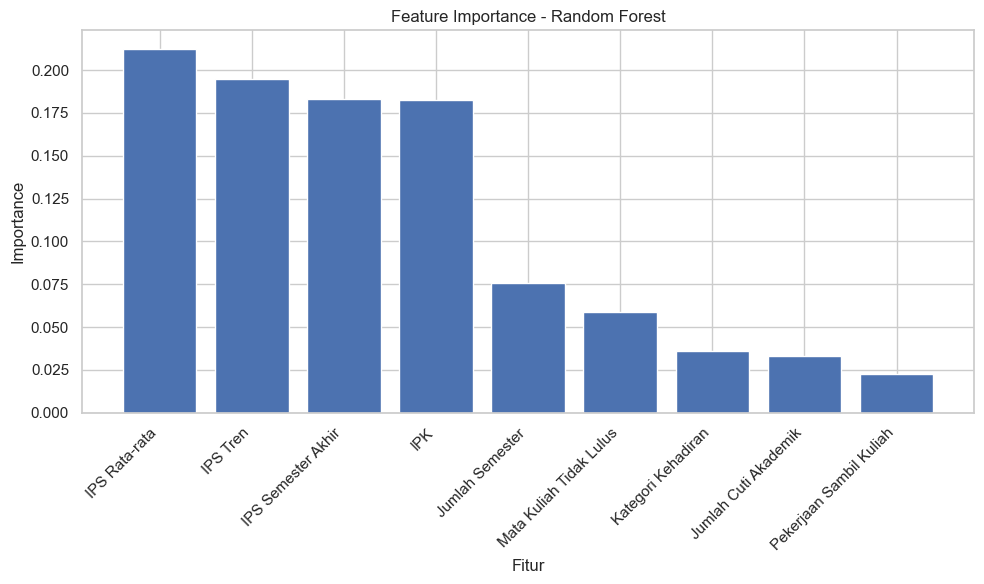


Peringkat Fitur:
  IPS Rata-rata: 0.2126
  IPS Tren: 0.1950
  IPS Semester Akhir: 0.1833
  IPK: 0.1826
  Jumlah Semester: 0.0757
  Mata Kuliah Tidak Lulus: 0.0589
  Kategori Kehadiran: 0.0360
  Jumlah Cuti Akademik: 0.0333
  Pekerjaan Sambil Kuliah: 0.0227


In [11]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Fitur')
plt.ylabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

print("\nPeringkat Fitur:")
for i in indices:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

## Kesimpulan
Random Forest memberikan performa yang baik untuk prediksi kelulusan mahasiswa. Dari feature importance, dapat diketahui faktor-faktor apa yang paling memengaruhi kelulusan, seperti IPK, jumlah semester, dan kehadiran. Model ini tidak memerlukan feature scaling dan robust terhadap data tidak seimbang maupun outlier.